# 분석 단계별 프로세스 - 순환 신경망 알고리즘

## 1. 라이브러리 / 데이터 불러오기

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

DATA_DIR = Path("../data")

df = pd.read_csv(DATA_DIR / "okm_augumented_2021.csv")

## 2. 데이터 종류 및 개수 확인

In [2]:
# 전체 데이터셋 출력
df

# 상위 기본 5개 데이터 확인
df.head()

# head 와 반대로 뒤에서부터 데이터 확인
df.tail()

# 데이터 전체 구조 및 타입 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


## 3. 데이터 정제(전처리)

#### 3-1. 결측치 처리

In [3]:
# 결측치 개수 확인
df.isnull().sum()

# fillna()를 이용해 특정 변수 결측치 값 채우기
# df.fillna({'강수량': 0}, inplace = True)
df.fillna(0, inplace=True)

df_frame = df
df.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

#### 3-2. 데이터 특성 파악

<Axes: >

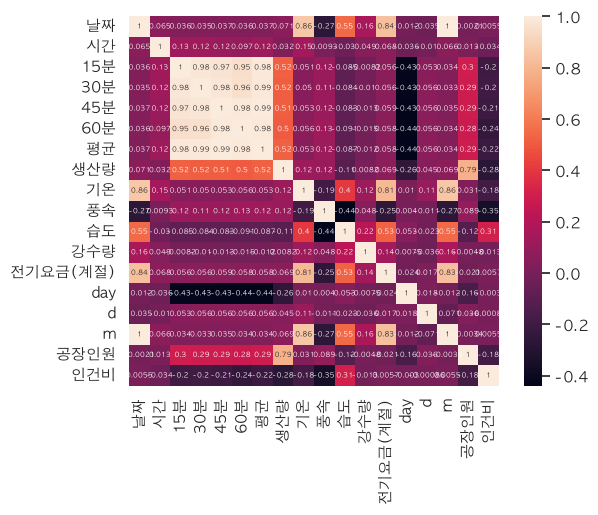

In [4]:
# 요약통계량 확인
df.describe()

# 각 데이터 간 상관관계 확인
df.corr()

plt.rc("font", family="AppleGothic")
sns.set(font="AppleGothic", rc={"axes.unicode_minus": False}, style="darkgrid")
sns.heatmap(df.corr(), vmax=1, square=True, annot=True, annot_kws={"size": 5})

#### 3-3. 데이터 정제

In [5]:
# 사용하지 않는 컬럼 제거
df = df.drop(columns=['생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비'])
df

# 대상 변수 이름 변경
df = df.rename(columns={"15분": 'Peak Consumption in 15 minute',
                        "30분": 'Peak Consumption in 30 minute',
                        "45분": 'Peak Consumption in 45 minute',
                        "60분": 'Peak Consumption in 60 minute',
                        "평균": 'Average Peak Consumption in 1 hour'})



In [6]:
# index의 날짜 시간대로 변경 
index_column = pd.date_range(start ='2021-01-01 00:00', end ='2021-09-14 23:00', freq ='h')
index_column

df.index =  index_column
df.index.names = ["Date"]
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [7]:
df.index = index_column
df.index.names = ["Date"]
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [8]:
df = df.drop(columns = ["날짜", "시간"])
df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62,61,61,61,61
2021-01-01 01:00:00,96,93,116,113,105
2021-01-01 02:00:00,106,96,106,107,104
2021-01-01 03:00:00,92,110,110,109,105
2021-01-01 04:00:00,108,105,106,108,107
...,...,...,...,...,...
2021-09-14 19:00:00,152,151,171,139,153
2021-09-14 20:00:00,124,130,128,130,128
2021-09-14 21:00:00,134,130,125,124,128


In [9]:
df['Peak Consumption in 15 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 30 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 45 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 60 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107


#### 3-4. 데이터 시각화 및 파일 저장

In [10]:
sns.set(rc = {'figure.figsize': (20, 10)})

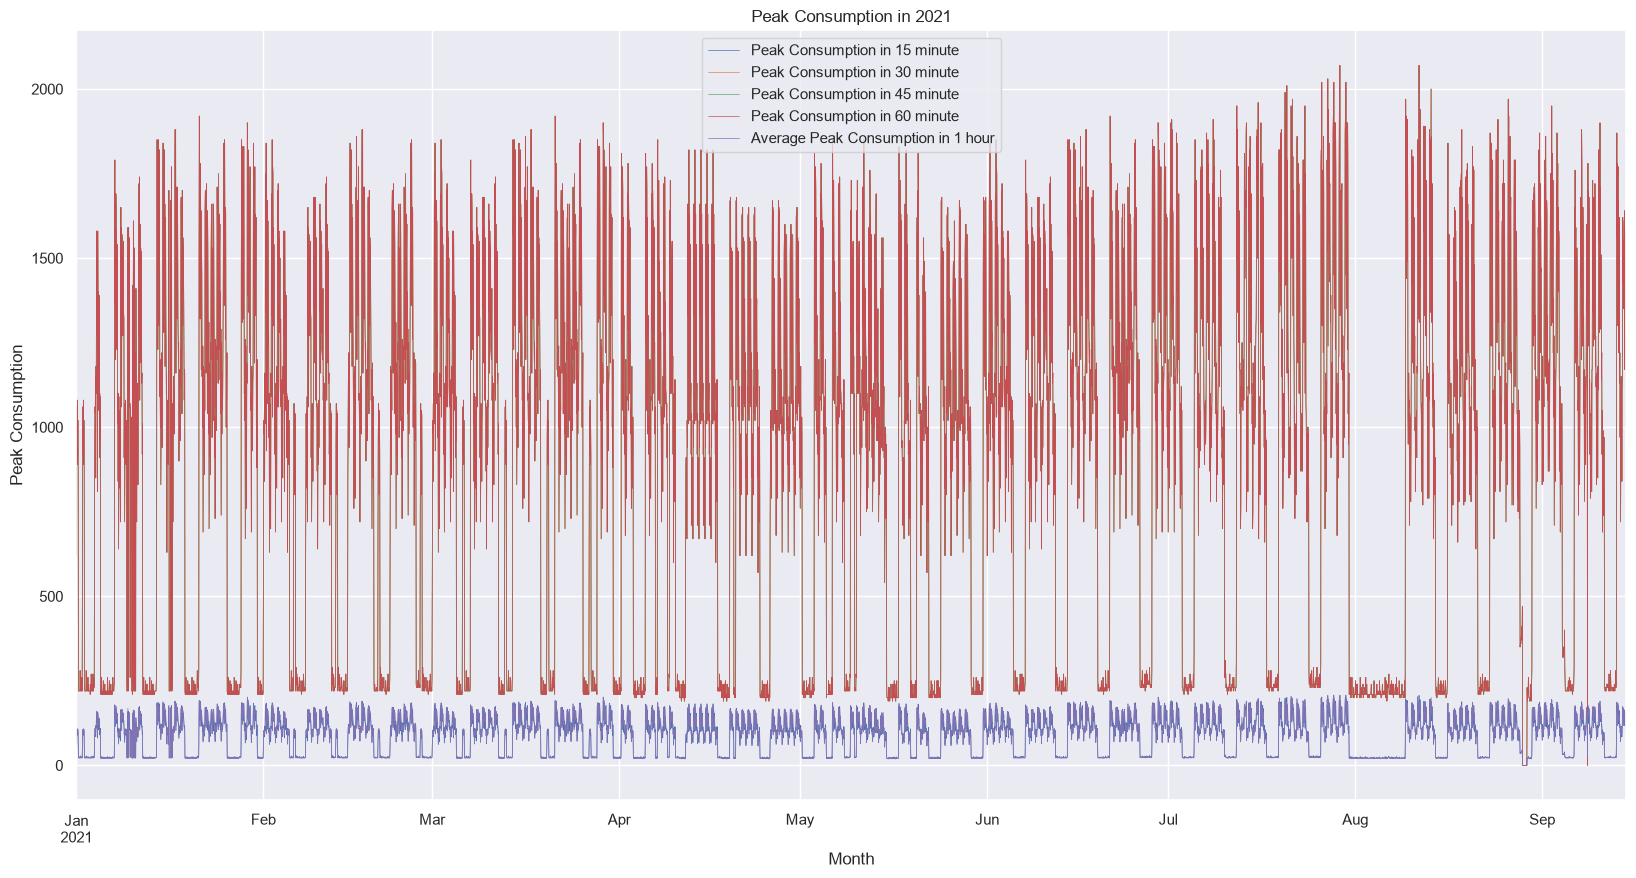

In [ ]:
# 2021년도 최대수요전력 값 시각화
df.loc["2021"].plot(linewidth=0.5)

plt.title("Peak Consumption in 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

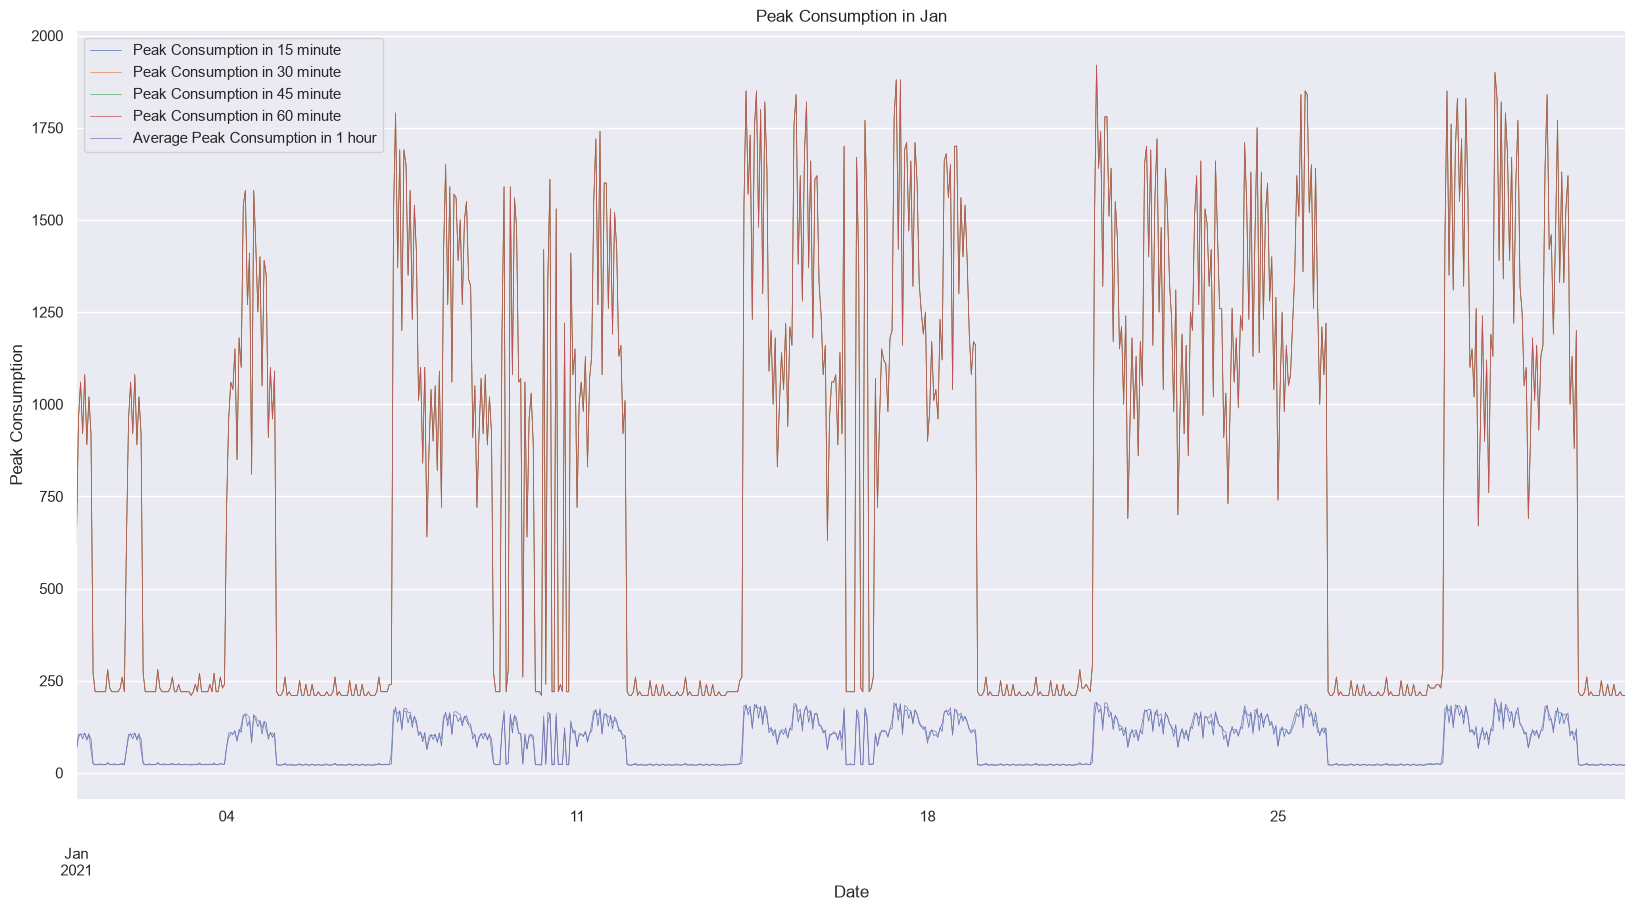

In [ ]:
# 2021년도 1월 최대수요전력 값 시각화
df.loc["2021-01"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan")
plt.ylabel("Peak Consumption")
plt.show()

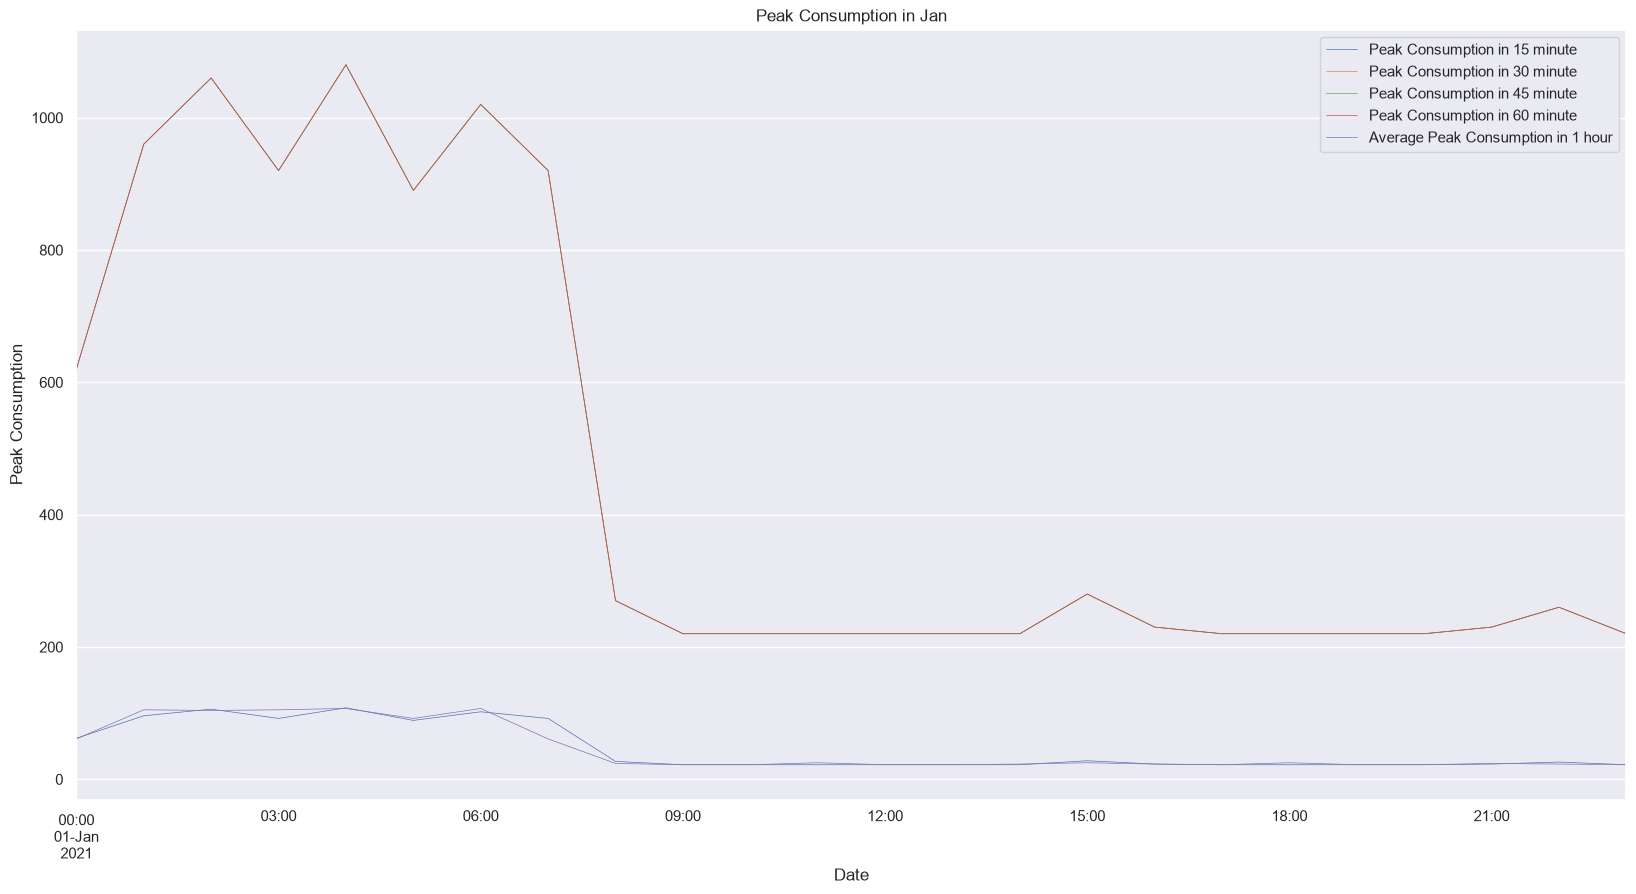

In [ ]:
# 2021년도 1월 1일 최대수요전력 값 시각화
df.loc["2021-01-01"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan 1st")
plt.ylabel("Peak Consumption")
plt.show()

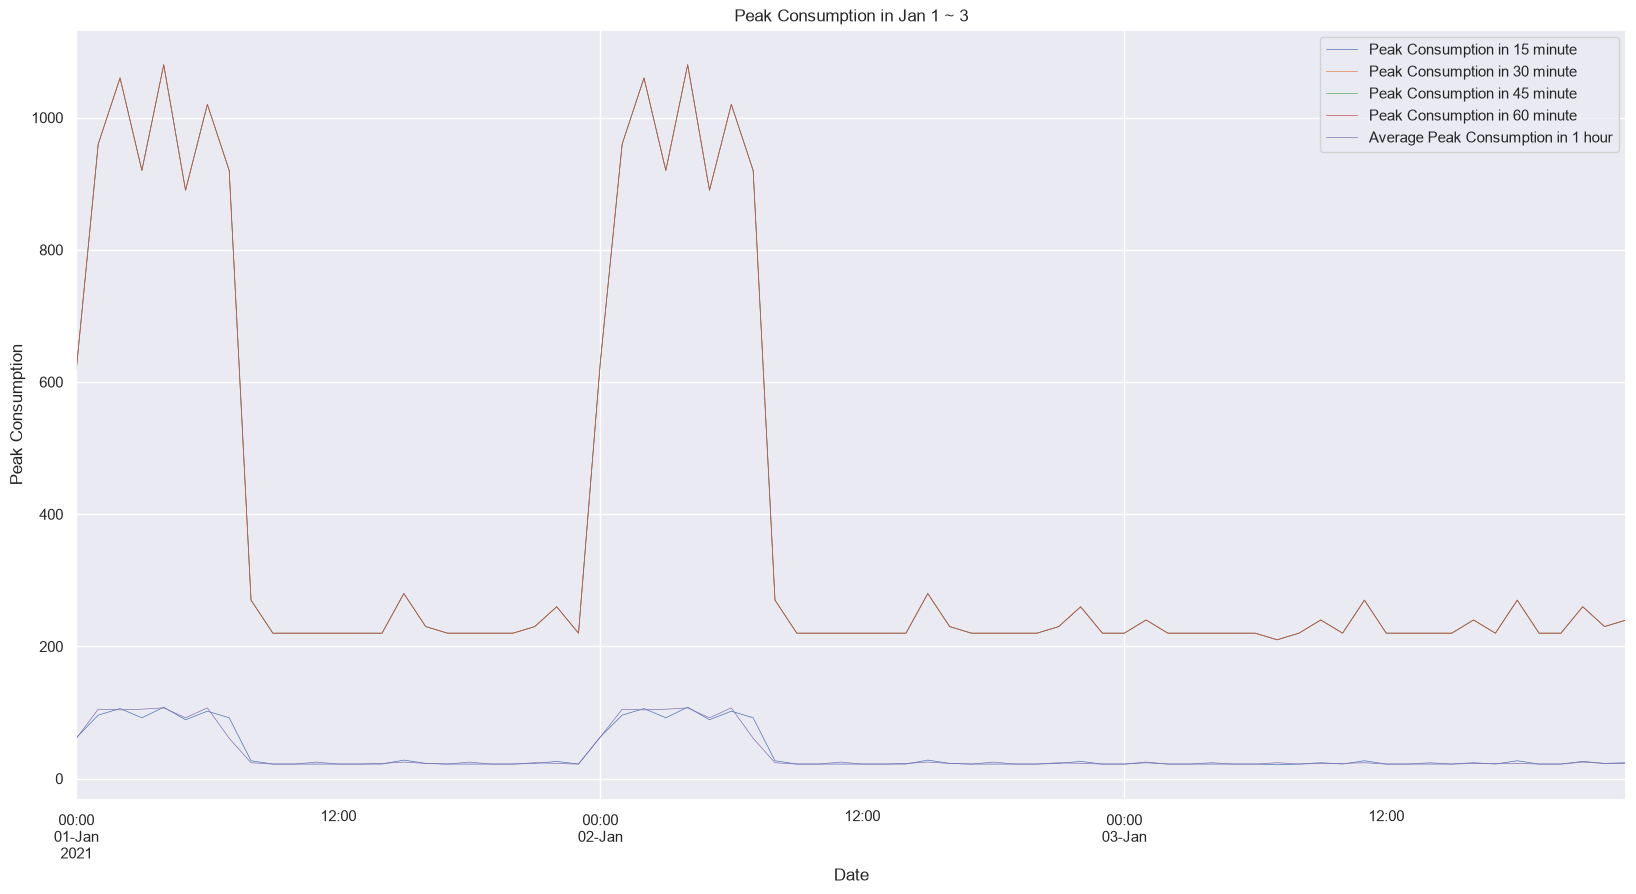

In [14]:
# 2021년도 1월 1일부터 3일까지의 최대수요전력 값 시각화
df.loc["2021-01":"2021-01-03"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan 1 ~ 3")
plt.ylabel("Peak Consumption")
plt.show()

#### 3-5. 주말 및 공휴일 데이터 구분

In [15]:
df["Vacation"] = np.zeros(len(df))
df["Weekend"] = np.zeros(len(df))
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107,0.0,0.0


In [ ]:
# dayofweek를 활용한 요일 값 확인하기
df.loc["2021-01-01"].index.dayofweek

Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype='int32', name='Date')

In [27]:
df.loc[
    (df.index.dayofweek == 5) | (df.index.dayofweek == 6),
    "Weekend"
] = 1

df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107,0.0,0.0
...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,1520.0,1520.0,1520.0,153,0.0,0.0
2021-09-14 20:00:00,124.0,1240.0,1240.0,1240.0,128,0.0,0.0
2021-09-14 21:00:00,134.0,1340.0,1340.0,1340.0,128,0.0,0.0


In [28]:
# 공휴일 변수 선언하기
holidays = ["2021-01-01", "2021-02-11", "2021-02-12","2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]

In [ ]:
# 반복문 활용해서 값 부여하기
for gun,j in df.iterrows():
    if str(gun)[:10] in holidays:
        df.loc[gun, "Vacation"] =1

df.head(5)

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61,1.0,0.0
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105,1.0,0.0
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104,1.0,0.0
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105,1.0,0.0
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107,1.0,0.0


In [38]:
# csv 파일 저장하기
df.to_csv("../results/daily_data_seasonality.csv", index=True)

#### 3-6. Window Features 생성
- window란 : 시간 단위
- 일주일 24시간 이므로 7*24 = 168

In [ ]:
# 파일 불러오기
daily_data = pd.read_csv(
    "../results/daily_data_seasonality.csv",
    header=0,
    index_col=0,
    parse_dates=True
)

In [43]:
daily_data =daily_data[["Peak Consumption in 15 minute"]]
daily_data

,Peak Consumption in 15 minute
Date,
2021-01-01 00:00:00,62.0
2021-01-01 01:00:00,96.0
2021-01-01 02:00:00,106.0
2021-01-01 03:00:00,92.0
2021-01-01 04:00:00,108.0
...,...
2021-09-14 19:00:00,152.0
2021-09-14 20:00:00,124.0
2021-09-14 21:00:00,134.0


In [ ]:
n_times_advance = 1
n_times_windows =168

In [47]:
for k in range(n_times_advance, n_times_advance + n_times_windows):
    daily_data["Peak Consumption in 15 minute_t-%i" % k] = np.zeros(
        len(daily_data["Peak Consumption in 15 minute"])
    )

daily_data

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 01:00:00,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 02:00:00,106.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 03:00:00,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 04:00:00,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-09-14 20:00:00,124.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-09-14 21:00:00,134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
target_col = "Peak Consumption in 15 minute"

for i in range(
    n_times_advance + n_times_windows,
    len(daily_data)
):
    for j in range(
        n_times_advance,
        n_times_advance + n_times_windows
    ):
        lag_col = f"Peak Consumption in 15 minute_t-{j}"

        daily_data.iloc[
            i,
            daily_data.columns.get_loc(lag_col)
        ] = daily_data.iloc[
            i - j,
            daily_data.columns.get_loc(target_col)
        ]

In [51]:
daily_data.to_csv("../results/daily_data_seasonality_168.csv", index = True)
daily_data.head(3)

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 01:00:00,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 02:00:00,106.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
